# **Módulo 5: Modelos Avançados e Comparação**
---

Neste notebook, avançaremos para modelos capazes de capturar relações não lineares e complexas nos dados. Utilizaremos o dataset já pré-processado para focar na aplicação e ajuste de:


*   Árvores de Decisão (Decision Tree)
*   Random Forest (Métodos Ensemble)
*   Suporte Vetorial para Regressão (SVR)

O objetivo é:


*   Entender o funcionamento de cada modelo
*   Comparar desempenho entre eles
*   Avaliar vantagens e limitações

## **Carregamento de Dados e Configuração Inicial**

Assim como no módulo anterior, começamos importando as bibliotecas e carregando nossos dados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [ ]:
url = "https://raw.githubusercontent.com/TreinamentoICCInatel/Curso_Regressao_na_Pratica/refs/heads/main/Arquivos/housing_tratado.csv"
housing = pd.read_csv(url)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,0.0,0.0,0.0,1.0,0.0
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,0.0,0.0,0.0,1.0,0.0
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,0.0,0.0,0.0,1.0,0.0
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,0.0,0.0,0.0,1.0,0.0
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,0.0,0.0,0.0,1.0,0.0


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-8.548545e-15,-1.079584e-15,1.652425e-17,3.442552e-17,-9.088337e-17,-1.101617e-17,7.435912e-17,8.262125e-17,-9.363741e-17,0.442636,0.317393,0.000242,0.110950,0.128779
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,0.496710,0.465473,0.015563,0.314077,0.334963
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.277688e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-1.662641e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.718868e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-7.561633e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.428309e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-2.353337e-01,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.537334e-01,2.644949e-01,2.758427e-01,4.593063e-01,5.014973e-01,1.000000,1.000000,0.000000,0.000000,0.000000
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.408779e+01,3.025033e+01,1.460152e+01,5.858286e+00,2.540411e+00,1.000000,1.000000,1.000000,1.000000,1.000000


Separar variável alvo (y) e variáveis explicativas (X)

In [ ]:
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

Dividimos os dados em:
- 80% para treino
- 20% para teste

Esse procedimento será mantido igual para todos os modelos,
permitindo uma comparação justa.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Árvore de Decisão (Decision Tree Regressor)**

A árvore de decisão divide o espaço de dados em regiões,
criando regras do tipo:

- se x < valor → previsão A
- se x ≥ valor → previsão B

Vantagens:
- Fácil interpretação
- Captura relações não lineares

Desvantagens:
- Alto risco de overfitting

### **Treinando a árvore de decisão**

Nesta etapa, estamos construindo uma **Árvore de Decisão para Regressão** (`DecisionTreeRegressor`).

1.  **`dt = DecisionTreeRegressor(max_depth=10, random_state=42)`**:
    *   `DecisionTreeRegressor`: É o modelo que estamos usando. Ele aprende a prever um valor contínuo (como o `median_house_value`) dividindo os dados em regiões com base em regras simples (por exemplo, `se latitude < X`).
    *   `max_depth=10`: Este é um parâmetro importante. Ele limita a profundidade máxima da árvore. Escolhemos `10` como um ponto de partida para equilibrar a complexidade do modelo.
    *   `random_state=42`: Garante que os resultados sejam reproduzíveis.

2.  **`dt.fit(X_train, y_train)`**:
    *   Esta é a fase de **treinamento**. O modelo `dt` "aprende" com os dados de treinamento (`X_train` - as características, e `y_train` - os valores que queremos prever). Ele analisa as características e cria as regras de decisão que dividem o espaço dos dados para minimizar o erro de previsão.

3.  **`y_pred_dt = dt.predict(X_test)`**:
    *   Após o treinamento, usamos o modelo para fazer **previsões** nos dados de teste (`X_test`). É importante usar dados que o modelo *nunca viu* durante o treinamento para avaliar seu desempenho real. `y_pred_dt` armazena os valores de preço de casas previstos pelo modelo para o conjunto de teste.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### **Visualizando resultados**

Na célula a seguir, será gerado um gráfico que compara os valores reais com as previsões do modelo, além de incluir uma linha de referência (em vermelho) representando o cenário de previsão perfeita.

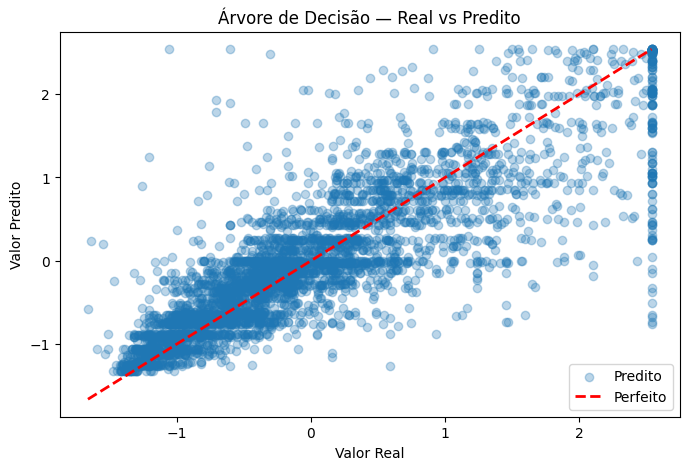

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_dt, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("Árvore de Decisão — Real vs Predito")
plt.show()


**O que observar no gráfico:**

*   **Dispersão dos Pontos**: Quanto mais próximos os pontos azuis estiverem da linha vermelha, melhor o desempenho do modelo. Uma grande dispersão (pontos muito afastados da linha) indica que o modelo está cometendo erros significativos.
*   **Tendência**: Idealmente, os pontos devem seguir a linha vermelha. Se houver uma curvatura ou um desvio consistente, isso pode indicar um viés no modelo (por exemplo, superestimando ou subestimando valores em certas faixas).
*   **Agrupamentos**: Pode-se observar se o modelo tem dificuldade em prever valores em faixas específicas (por exemplo, agrupamento de pontos abaixo da linha em valores altos, indicando subestimação de casas caras).

Neste gráfico, podemos ver que os pontos azuis estão razoavelmente próximos à linha vermelha, mas há uma dispersão notável, especialmente em valores mais altos. Isso sugere que a Árvore de Decisão com `max_depth=10` está capturando parte da relação nos dados, mas ainda há espaço para melhorias ou que ela comete erros em algumas previsões.

## **Random Forest Regressor**

O Random Forest é um conjunto (ensemble) de várias árvores de decisão.

Cada árvore:
- é treinada com subconjuntos dos dados
- usa subconjuntos das variáveis

A previsão final é a média das previsões das árvores.

Vantagens:
- Reduz overfitting
- Melhor generalização

Desvantagens:
- Menor interpretabilidade

### **Treinando o Random Forest**



Nesta etapa, estamos construindo um modelo **Random Forest para Regressão** (`RandomForestRegressor`).

1.  **`rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)`**:
    *   `RandomForestRegressor`: Este modelo é um *ensemble* de várias árvores de decisão. Ele combina as previsões de múltiplas árvores para obter uma previsão mais robusta e reduzir o *overfitting*.
    *   `n_estimators=200`: Define o número de árvores de decisão que serão construídas no *forest*. Um número maior de estimadores geralmente resulta em melhor desempenho, mas também aumenta o tempo de treinamento.
    *   `max_depth=6`: Limita a profundidade máxima de cada árvore individual no *forest*. Similar à Árvore de Decisão, isso ajuda a controlar a complexidade do modelo e evitar o *overfitting*.
    *   `random_state=42`: Garante a reprodutibilidade dos resultados.

2.  **`rf.fit(X_train, y_train)`**:
    *   Esta é a fase de **treinamento**. O modelo `rf` "aprende" com os dados de treinamento (`X_train` e `y_train`). Cada uma das 200 árvores é treinada em uma amostra diferente dos dados de treinamento e em um subconjunto de características (variáveis explicativas).

3.  **`y_pred_rf = rf.predict(X_test)`**:
    *   Após o treinamento, usamos o modelo para fazer **previsões** nos dados de teste (`X_test`). A previsão final de `y_pred_rf` é a média das previsões de todas as árvores individuais no *forest*.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


### **Visualizando resultados**

Iremos utilizar o mesmo método para a visualização dos resultados das previsões do Random Forest.

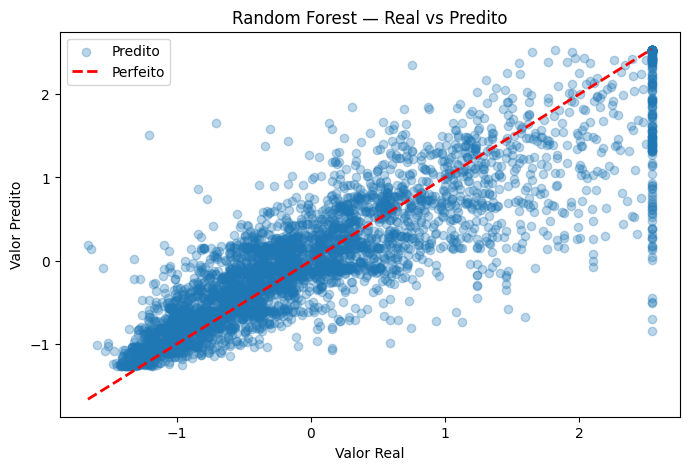

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("Random Forest — Real vs Predito")
plt.show()

Neste gráfico, podemos observar que o modelo Random Forest apresenta uma **melhora significativa** em comparação com a Árvore de Decisão individual. Os pontos azuis (previsões) estão **mais agrupados e próximos à linha vermelha** (previsão perfeita), especialmente em valores mais altos, onde a Árvore de Decisão mostrou maior dispersão.

**O que observar no gráfico:**

*   **Menor Dispersão**: A nuvem de pontos azuis é mais compacta em torno da linha vermelha, indicando que o Random Forest está fazendo previsões mais precisas e com menor variância.
*   **Melhor Generalização**: A redução da dispersão sugere que o modelo tem uma capacidade melhor de generalizar para novos dados, minimizando o risco de *overfitting* que é comum em árvores de decisão individuais.
*   **Consistência**: O modelo parece manter uma boa performance em diferentes faixas de valores, com menos desvios óbvios em valores extremos. Ainda pode haver alguma dispersão, mas é menos pronunciada.

Em resumo, o Random Forest demonstra ser um modelo mais robusto e com melhor desempenho na previsão do `median_house_value` em comparação com a Árvore de Decisão, o que era esperado devido à sua natureza de *ensemble* que combina múltiplas árvores para reduzir vieses e variâncias.

## **Support Vector Regression**

O SVR busca ajustar uma função que:
- tenha erro menor que um limite ε
- seja a mais plana possível

Características importantes:
- Sensível à escala dos dados
- Kernel RBF permite modelar não linearidades

### **Treinando o SVR**



Nesta etapa, estamos construindo um modelo **Support Vector Regressor (SVR)**.

1.  **`svr = SVR(kernel='poly', degree=2, C=10, epsilon=0.1)`**:
    *   `SVR`: É o modelo que estamos utilizando para regressão. Ele busca encontrar uma função que se ajuste aos dados, permitindo um certo erro (epsilon) e penalizando erros maiores.
    *   `kernel='poly, degree=2'`: Define a função de mapeamento polinomial que projeta os dados em um espaço de maior dimensão, permitindo modelar interações quadráticas e curvas parabólicas para separar classes que não são linearmente divisíveis.
    *   `C=10`: É o parâmetro de regularização. Ele controla a penalidade por pontos de dados que violam a margem de erro. Um `C` maior significa menos tolerância a erros e pode levar a um modelo mais complexo (e potencialmente a overfitting).
    *   `epsilon=0.1`: Define a largura da margem de tolerância (o "tubo" em torno da função de regressão) onde nenhum erro é penalizado. Previsões dentro desta margem são consideradas corretas.

2.  **`svr.fit(X_train_scaled, y_train)`**:
    *   Esta é a fase de **treinamento**. O modelo `svr` aprende a partir dos dados de treinamento escalados (`X_train_scaled` - as características) e os valores alvo (`y_train`).

3.  **`y_pred_svr = svr.predict(X_test_scaled)`**:
    *   Após o treinamento, usamos o modelo para fazer **previsões** nos dados de teste escalados (`X_test_scaled`). `y_pred_svr` armazena os valores previstos pelo modelo para o conjunto de teste.

É crucial notar que tanto os dados de treinamento quanto os de teste foram escalados usando o *mesmo* `scaler` treinado apenas com os dados de treinamento. Isso evita o vazamento de informações do conjunto de teste para o treinamento.

In [ ]:
from sklearn.svm import SVR

svr = SVR(kernel="poly", degree= 2, C=10, epsilon=0.1)
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)


### **Visualizando resultados do SVR**

Agora vamos gerar o gráfico para visualização dos resultados do SVR.

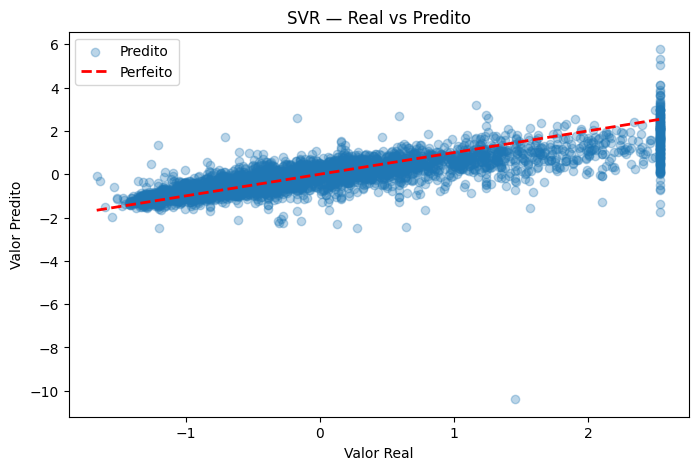

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_svr, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("SVR — Real vs Predito")
plt.show()

Neste gráfico, observamos o desempenho do modelo SVR. Embora ele consiga capturar a tendência central dos dados (seguindo a linha vermelha de previsão perfeita), ele apresenta comportamentos distintos em relação à dispersão e aos valores extremos (outliers).

**O que observar no gráfico:**

- **Dispersão Linear e Estreita:** A nuvem de pontos azuis mostra-se bastante concentrada em torno da linha de perfeição na faixa central de valores. Isso indica que, para a maioria dos dados, o SVR possui uma baixa variância e consegue manter uma consistência preditiva sólida.
- **Sensibilidade a Outliers:** É possível notar alguns pontos significativamente distantes da massa principal (como o ponto isolado próximo ao valor -10 no eixo Y). Isso sugere que o SVR, dependendo da configuração do parâmetro de penalização ($C$) e do epsilon, pode ser influenciado por valores atípicos ou apresentar erros pontuais graves.
- **Comportamento em Valores Máximos:** Assim como no Random Forest, há uma "parede" vertical no lado direito do gráfico (próximo ao valor real 2.5). O SVR parece ter dificuldade em prever valores além desse teto, subestimando muitos desses casos, embora alguns pontos de predição disparem para cima (indicando alta sensibilidade nessa franja).

## **Comparação matemática dos modelos**

Nesta seção, realizaremos uma comparação quantitativa do desempenho dos modelos utilizando o **Root Mean Squared Error (RMSE)**. O RMSE é uma métrica que mede a média dos erros das previsões de um modelo, penalizando erros maiores de forma mais severa. Quanto menor o valor do RMSE, melhor o modelo se ajusta aos dados.

Vamos calcular o RMSE para cada modelo treinado e apresentar os resultados em uma tabela para facilitar a visualização e a comparação.

In [ ]:
from sklearn.metrics import mean_squared_error
results = pd.DataFrame([
    {"Modelo": "Decision Tree", "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_dt))},
    {"Modelo": "Random Forest", "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))},
    {"Modelo": "SVR", "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_svr))}
])

display(results)

,Modelo,RMSE
0,Decision Tree,0.527978
1,Random Forest,0.502380
2,SVR,0.600141


A tabela acima apresenta os valores de **RMSE** para cada um dos modelos. Podemos observar claramente que:

*   O **Random Forest** obteve o menor RMSE, indicando que foi o modelo com as previsões mais precisas neste conjunto de dados, com a menor média de erros quadráticos.
*   A **Decision Tree** teve um RMSE maior que o Random Forest, o que é esperado, pois o Random Forest é um método ensemble que combina múltiplas árvores para reduzir a variância e melhorar a generalização.
*   O **SVR** apresentou o maior RMSE entre os três modelos, sugerindo que, com a configuração de hiperparâmetros atual (`kernel='poly', degree=2, C=10, epsilon=0.1`), ele não conseguiu performar tão bem quanto os modelos baseados em árvores para este problema.

É importante notar que, embora o gráfico do SVR possa, em algumas interpretações visuais, parecer 'limpo' ou linear no centro, o RMSE revela um desempenho menos preciso. Isso ocorre porque o SVR, nesta configuração, demonstra:
*   **Maior sensibilidade a outliers e erros nos extremos**: Pontos significativamente distantes da linha de previsão (especialmente em valores máximos ou em outliers) são penalizados severamente pelo RMSE, elevando seu valor total.
*   **Menor consistência geral**: Apesar de uma boa performance em uma faixa central de valores, o SVR pode ter dificuldades em generalizar para todo o espectro dos dados, resultando em erros maiores em outras regiões. O Random Forest, por outro lado, mesmo que seu gráfico possa parecer mais 'disperso' à primeira vista, apresenta uma nuvem de pontos mais consistentemente próxima da linha de previsão perfeita em todas as faixas de valores, resultando em um RMSE menor.

Essa análise numérica complementa as observações visuais dos gráficos de dispersão, confirmando a superioridade do Random Forest para este problema de regressão em termos de precisão geral (RMSE), e ressaltando a necessidade de otimização de hiperparâmetros e/ou experimentação com outros kernels para o SVR.

## **Interpretação dos Gráficos de Resíduos**

A análise dos gráficos de resíduos é fundamental para complementar as métricas de erro como o RMSE, pois revela a natureza dos erros de previsão de um modelo. Idealmente, esperamos que os resíduos estejam distribuídos aleatoriamente em torno de zero, sem nenhum padrão discernível, o que indicaria que o modelo capturou bem as relações nos dados e que os erros são ruído aleatório.



In [ ]:
import statsmodels.api as sm

# Calcular resíduos do conjunto de teste para cada modelo
residuals_dt = y_test - y_pred_dt
residuals_rf = y_test - y_pred_rf
residuals_svr = y_test - y_pred_svr

### **1. Resíduos vs. Valores Preditos (Decision Tree)**

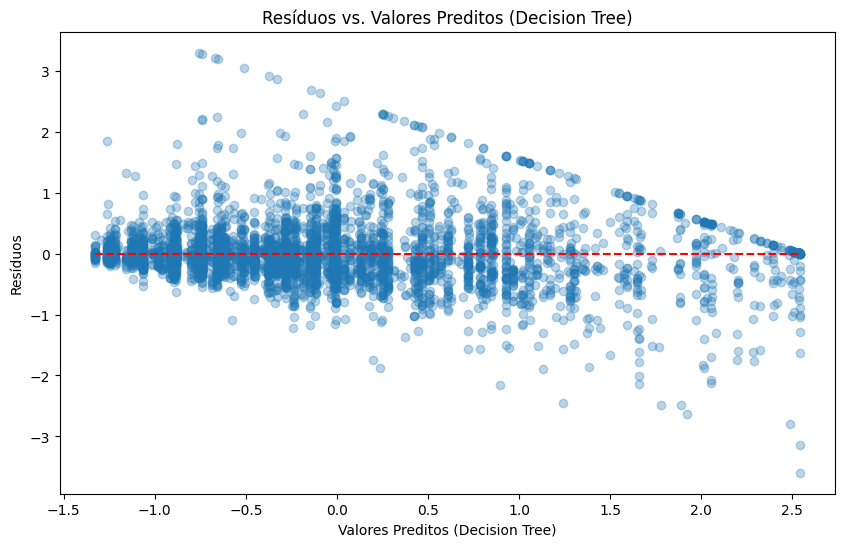

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_dt, residuals_dt, alpha=0.3)
plt.hlines(0, y_pred_dt.min(), y_pred_dt.max(), colors='r', linestyles='--')
plt.xlabel('Valores Preditos (Decision Tree)')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Preditos (Decision Tree)')
plt.show()



*   **Observações**: No gráfico da Árvore de Decisão, podemos notar uma dispersão considerável dos pontos azuis, e um padrão que se assemelha a uma 'nuvem' com formato irregular. Há pontos de resíduos muito altos e muito baixos, especialmente para valores preditos na faixa central.
*   **Interpretação**: A falta de uma distribuição aleatória em torno de zero e a presença de uma grande dispersão, especialmente para determinados intervalos de valores preditos, sugerem que a Árvore de Decisão individual pode estar sofrendo de **overfitting** ou não está capturando adequadamente todas as relações complexas dos dados. Ela parece ter dificuldades em generalizar, resultando em erros maiores e mais variados.

### **2. Resíduos vs. Valores Preditos (Random Forest)**

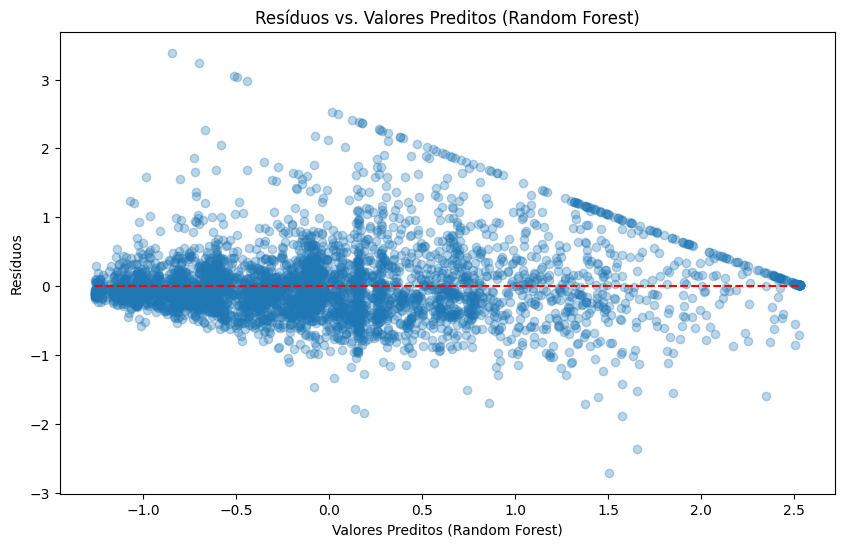

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.3)
plt.hlines(0, y_pred_rf.min(), y_pred_rf.max(), colors='r', linestyles='--')
plt.xlabel('Valores Preditos (Random Forest)')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Preditos (Random Forest)')
plt.show()



*   **Observações**: O gráfico do Random Forest apresenta uma nuvem de pontos azuis visivelmente mais compacta e mais próxima da linha horizontal zero em comparação com a Árvore de Decisão. A dispersão parece ser mais uniforme em todo o intervalo de valores preditos, e a concentração de pontos ao redor da linha zero é maior.
*   **Interpretação**: Este padrão é o mais próximo do ideal. A distribuição mais aleatória e menos dispersa dos resíduos sugere que o Random Forest é um modelo mais robusto e com melhor capacidade de generalização. Os erros são menores e não exibem um padrão sistemático claro, indicando que o modelo capturou a maioria das informações relevantes e que os erros restantes são principalmente ruído aleatório. Isso está alinhado com o menor RMSE obtido por este modelo.

### **3. Resíduos vs. Valores Preditos (SVR)**

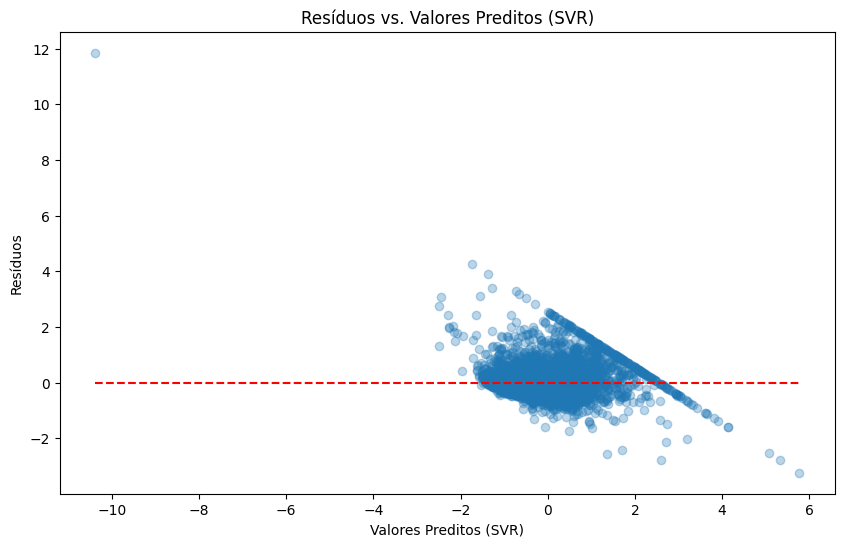

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_svr, residuals_svr, alpha=0.3)
plt.hlines(0, y_pred_svr.min(), y_pred_svr.max(), colors='r', linestyles='--')
plt.xlabel('Valores Preditos (SVR)')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Preditos (SVR)')
plt.show()

*   **Observações**: O gráfico do SVR mostra uma concentração de resíduos próximos a zero na faixa central de valores preditos, o que pode dar uma falsa impressão de bom ajuste. No entanto, observamos pontos de resíduos significativamente distantes da linha zero, especialmente nas extremidades dos valores preditos (tanto para valores preditos muito baixos quanto muito altos). Há também uma tendência de os resíduos apresentarem um formato de 'cone' ou 'leque', com maior dispersão nas extremidades.

*   **Interpretação**: Este padrão sugere que o SVR, com a configuração atual, pode ter problemas de **heterocedasticidade**, ou seja, a variância dos erros não é constante em todo o intervalo de previsões. A maior dispersão nas extremidades indica que o modelo é menos confiável e comete erros maiores para valores de casas muito baixos ou muito altos. A 'parede' vertical visível na dispersão real vs. predita, onde o SVR tende a subestimar valores muito altos, também se reflete aqui com grandes resíduos negativos para previsões altas. Isso contribui para o RMSE mais elevado do SVR em comparação com o Random Forest, mesmo que o centro do gráfico pareça bem ajustado.

## **Conclusão Geral dos Modelos**



Ao comparar os três modelos – Árvore de Decisão, Random Forest e SVR – utilizando tanto a métrica quantitativa **RMSE** quanto a análise qualitativa dos **gráficos de resíduos**, podemos extrair uma conclusão clara sobre seu desempenho para este problema de regressão.

### **Análise Quantitativa (RMSE):**

Os valores de RMSE obtidos foram:

*   **Decision Tree:** 0.527978
*   **Random Forest:** 0.502380
*   **SVR:** 0.600141

Nesta análise, o **Random Forest** apresentou o menor RMSE, indicando que, em média, suas previsões são as mais próximas dos valores reais, resultando na **maior precisão** entre os três modelos.

### **Análise Qualitativa (Gráficos de Resíduos):**

*   **Decision Tree:** O gráfico de resíduos da Árvore de Decisão mostrou uma dispersão considerável e irregular, com muitos pontos distantes da linha zero. Isso sugere que o modelo sofre de **overfitting** ou não está generalizando bem para novos dados, apresentando alta variância nos erros.

*   **Random Forest:** Este modelo exibiu o gráfico de resíduos mais próximo do ideal. A nuvem de pontos estava visivelmente mais compacta e centrada em torno da linha zero, com uma distribuição aleatória e sem padrões discerníveis. Isso indica uma excelente **capacidade de generalização** e que os erros são predominantemente ruído aleatório, corroborando o baixo RMSE.

*   **SVR:** O SVR apresentou um comportamento de resíduos com concentração próxima a zero na faixa central, mas com uma dispersão crescente nas extremidades (formato de 'cone' ou 'leque'). Isso sugere **heterocedasticidade**, onde a variância dos erros não é constante. O modelo parece ter dificuldades em prever valores muito baixos ou muito altos, levando a erros maiores nesses extremos e, consequentemente, a um RMSE mais elevado.

### **Conclusão:**

Considerando tanto a **precisão** (menor RMSE) quanto a **generalização** (distribuição aleatória e compacta dos resíduos) e a **distribuição de erros**, o **Random Forest** foi o modelo que apresentou o **melhor desempenho** para este problema. Ele conseguiu capturar as relações nos dados de forma mais robusta e consistente, resultando em previsões mais acuradas e com menor variância de erro em todo o espectro de valores.

Embora a Árvore de Decisão seja interpretável, sua tendência ao overfitting a torna menos confiável. O SVR, apesar de sua capacidade de modelar não linearidades, não se ajustou tão bem com a configuração atual, mostrando sensibilidade a valores extremos e heterocedasticidade. O Random Forest, por sua natureza de *ensemble*, mitigou as desvantagens da Árvore de Decisão, entregando um modelo mais poderoso e confiável.

---
Neste módulo, pudemos observar na prática como testar e interpretar o funcionamento de diferentes modelos de regressão. Através de experimentos e da análise de métricas como o RMSE e os gráficos de resíduos, aprendemos a selecionar o modelo que melhor se adequa a cada caso.

Sinta-se à vontade para continuar testando, ajustando hiperparâmetros e explorando outras técnicas para desenvolver ainda mais seu senso crítico e sua habilidade de criar modelos de regressão poderosos e eficientes!